## imports y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset/strava_data.csv')

## Analisis exploratorio de datos

In [3]:
# Filtramos por el tipo de deporte que queremos, ride = ciclismo
df = df[df['sport_type'] == 'Ride']

# Columnas que necesitamos
df = df[[
    "name",
    "distance",
    "moving_time",
    "total_elevation_gain",
    "average_speed",
    "sport_type",
    "date"
]]

# Verificamos datos nulos
df.isnull().sum()

# Verificamos duplicados y los eliminamos
df.duplicated().sum()
df = df.drop_duplicates()

df = df[df["average_speed"] > 5]   # elimina registros casi estáticos
df = df[df["average_speed"] < 60]  # elimina velocidades imposibles

# Convertimos las unidades de medida
# millas -> km
df["distance"] = df["distance"] * 1.60934

# millas por hora -> km/h
df["average_speed"] = df["average_speed"] * 1.60934

# pies -> metros
df["total_elevation_gain"] = df["total_elevation_gain"] * 0.3048

# convertir date de string a tipo fecha
df["date"] = pd.to_datetime(df["date"])

# Renombrar columnas
df = df.rename(columns={
    "distance": "distance_km",
    "average_speed": "average_speed_kmh",
    "total_elevation_gain": "elevation_m"
})

df["distance_km"] = df["distance_km"].round(2)
df["average_speed_kmh"] = df["average_speed_kmh"].round(2)
df["elevation_m"] = df["elevation_m"].round(2)

df.head()

,name,distance_km,moving_time,elevation_m,average_speed_kmh,sport_type,date
8,bikini,80.55,168.63,1040.0,28.66,Ride,2023-08-19 06:29:26
15,Evening Ride,3.44,13.15,19.0,15.71,Ride,2023-08-13 19:39:30
17,Morning Ride,0.53,1.47,1.0,21.60,Ride,2023-08-12 10:21:07
18,shift in the force,80.80,158.72,404.0,30.55,Ride,2023-08-12 07:31:32
24,Fresh Daily,76.70,156.75,722.0,29.35,Ride,2023-08-05 07:00:43


In [4]:
df.describe()

,distance_km,moving_time,elevation_m,average_speed_kmh,date
count,495.000000,495.000000,495.000000,495.000000,495
mean,37.069960,80.491737,235.819394,25.702364,2021-02-09 22:13:00.024242
min,0.060000,0.250000,0.000000,8.420000,2017-04-26 18:49:11
25%,13.890000,37.290000,23.500000,22.235000,2020-06-17 10:07:06.500000
50%,32.200000,70.000000,133.200000,27.390000,2021-05-14 06:00:42
75%,56.775000,121.065000,365.000000,30.060000,2022-01-17 08:08:32.500000
max,161.380000,309.800000,1648.000000,45.930000,2023-08-19 06:29:26
std,27.151165,52.563744,284.921816,6.689752,NaN


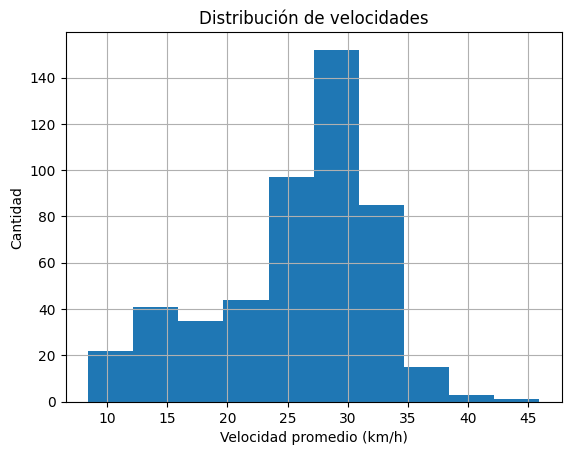

In [5]:
df["average_speed_kmh"].hist()

plt.xlabel("Velocidad promedio (km/h)")
plt.ylabel("Cantidad")
plt.title("Distribución de velocidades")
plt.show()

### La mayoría de ciclistas están entre: 20 y 35 km/h

### Se identificaron valores atípicos en la velocidad promedio, posiblemente causados por errores de medición o registros anómalos.

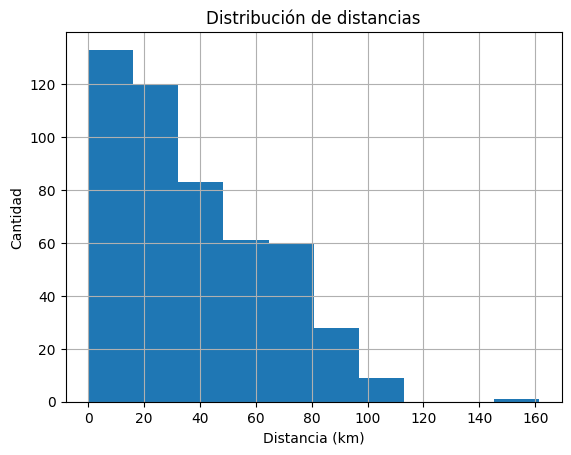

In [6]:
df["distance_km"].hist()

plt.xlabel("Distancia (km)")
plt.ylabel("Cantidad")
plt.title("Distribución de distancias")
plt.show()

### Que muestra este grafico?
#### La mayoría de rutas están entre: 0 y 40 km
#### Entonces la mayoría son recorridos cortos o medios pocas rutas son extremadamente largas

## Clasificacion de medidas

In [7]:
speed_conditions = [
    df["average_speed_kmh"] < 20,
    (df["average_speed_kmh"] >= 20) & (df["average_speed_kmh"] < 30),
    df["average_speed_kmh"] >= 30
]

speed_ranges = ["< 20 km/h", "20–30 km/h", "> 30 km/h"]
levels = ["Beginner", "Intermediate", "Advanced"]

df = df.assign(
    speed_range=np.select(speed_conditions, speed_ranges, default="unknown"),
    level=np.select(speed_conditions, levels, default="unknown")
)

df.head()

,name,distance_km,moving_time,elevation_m,average_speed_kmh,sport_type,date,speed_range,level
8,bikini,80.55,168.63,1040.0,28.66,Ride,2023-08-19 06:29:26,20–30 km/h,Intermediate
15,Evening Ride,3.44,13.15,19.0,15.71,Ride,2023-08-13 19:39:30,< 20 km/h,Beginner
17,Morning Ride,0.53,1.47,1.0,21.60,Ride,2023-08-12 10:21:07,20–30 km/h,Intermediate
18,shift in the force,80.80,158.72,404.0,30.55,Ride,2023-08-12 07:31:32,> 30 km/h,Advanced
24,Fresh Daily,76.70,156.75,722.0,29.35,Ride,2023-08-05 07:00:43,20–30 km/h,Intermediate


## Normalizacion

imagina una ruta con:

distance_km = 80 km
elevation_m = 600 m
average_speed_km/h = 30 km/h

Si simplemente sumas esos números con pesos, la elevación (600) va a dominar el score solo por ser un número grande, no porque sea más importante. Los números están en escalas completamente distintas.


La normalización lo que hace es llevar todo al mismo idioma: del 0 al 1.
La fórmula es simple, se llama Min-Max:


valor_normalizado = (valor - mínimo) / (máximo - mínimo)

La idea del scoring es asignarle a cada ruta un puntaje de dificultad del 0 al 1 combinando las 3 variables con pesos distintos, porque no todas importan igual:

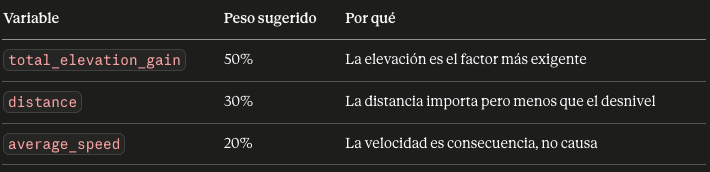


Cada variable se normaliza del 0 al 1 primero (para que no dominen las que tienen números grandes), y luego se multiplica por su peso:


score = (elev_norm × 0.5) + (dist_norm × 0.3) + (speed_norm × 0.2)
Después divides ese score en rangos:

0.0 – 0.33 → recomiéndalo a Beginner
0.33 – 0.66 → recomiéndalo a Intermediate
0.66 – 1.0 → recomiéndalo a Advanced

In [8]:
df = df.assign(
    elev_norm=(df["elevation_m"] - df["elevation_m"].min()) /
              (df["elevation_m"].max() - df["elevation_m"].min()),

    dist_norm=(df["distance_km"] - df["distance_km"].min()) /
              (df["distance_km"].max() - df["distance_km"].min()),

    speed_norm=(df["average_speed_kmh"] - df["average_speed_kmh"].min()) /
               (df["average_speed_kmh"].max() - df["average_speed_kmh"].min())
)

df.head()

,name,distance_km,moving_time,elevation_m,average_speed_kmh,sport_type,date,speed_range,level,elev_norm,dist_norm,speed_norm
8,bikini,80.55,168.63,1040.0,28.66,Ride,2023-08-19 06:29:26,20–30 km/h,Intermediate,0.631068,0.498946,0.539589
15,Evening Ride,3.44,13.15,19.0,15.71,Ride,2023-08-13 19:39:30,< 20 km/h,Beginner,0.011529,0.020952,0.194348
17,Morning Ride,0.53,1.47,1.0,21.60,Ride,2023-08-12 10:21:07,20–30 km/h,Intermediate,0.000607,0.002913,0.351373
18,shift in the force,80.80,158.72,404.0,30.55,Ride,2023-08-12 07:31:32,> 30 km/h,Advanced,0.245146,0.500496,0.589976
24,Fresh Daily,76.70,156.75,722.0,29.35,Ride,2023-08-05 07:00:43,20–30 km/h,Intermediate,0.438107,0.475081,0.557985


## Scoring ponderado

In [9]:
df = df.assign(
    difficulty_score=(
        df["elev_norm"] * 0.5 +
        df["dist_norm"] * 0.3 +
        df["speed_norm"] * 0.2
    )
)

df.head()

,name,distance_km,moving_time,elevation_m,average_speed_kmh,sport_type,date,speed_range,level,elev_norm,dist_norm,speed_norm,difficulty_score
8,bikini,80.55,168.63,1040.0,28.66,Ride,2023-08-19 06:29:26,20–30 km/h,Intermediate,0.631068,0.498946,0.539589,0.573136
15,Evening Ride,3.44,13.15,19.0,15.71,Ride,2023-08-13 19:39:30,< 20 km/h,Beginner,0.011529,0.020952,0.194348,0.050920
17,Morning Ride,0.53,1.47,1.0,21.60,Ride,2023-08-12 10:21:07,20–30 km/h,Intermediate,0.000607,0.002913,0.351373,0.071452
18,shift in the force,80.80,158.72,404.0,30.55,Ride,2023-08-12 07:31:32,> 30 km/h,Advanced,0.245146,0.500496,0.589976,0.390717
24,Fresh Daily,76.70,156.75,722.0,29.35,Ride,2023-08-05 07:00:43,20–30 km/h,Intermediate,0.438107,0.475081,0.557985,0.473174


## Funcion de recomendacion

In [10]:
def recommend_routes(level, df):
    if level == "Beginner":
        routes = df[df["difficulty_score"] <= 0.33]
    elif level == "Intermediate":
        routes = df[(df["difficulty_score"] > 0.33) & (df["difficulty_score"] <= 0.66)]
    elif level == "Advanced":
        routes = df[df["difficulty_score"] > 0.66]
    else:
        print("Nivel no válido. Usa: Beginner, Intermediate o Advanced")
        return None

    return routes.sort_values("difficulty_score")[
        ["name", "distance_km", "average_speed_kmh", "elevation_m", "speed_range", "difficulty_score"]
    ].head(10)

## Pruebas de la funcion

In [11]:
print("\n=== Rutas para Advanced ===")
print(recommend_routes("Advanced", df))


=== Rutas para Advanced ===
                   name  distance_km  average_speed_kmh  elevation_m  \
974        Morning Ride        83.03              22.40       1426.0   
981        Morning Ride        78.39              21.10       1483.0   
1622  Zwift - The Gorby        23.11              34.38       1607.4   
649        Morning Ride        67.32              19.15       1648.0   
617      Hardman Gravel        97.27              24.77       1504.0   

     speed_range  difficulty_score  
974   20–30 km/h          0.661482  
981   20–30 km/h          0.663215  
1622   > 30 km/h          0.668964  
649    < 20 km/h          0.682292  
617   20–30 km/h          0.724265  


In [12]:
print("\n=== Rutas para Intermediate ===")
print(recommend_routes("Intermediate", df))



=== Rutas para Intermediate ===
                   name  distance_km  average_speed_kmh  elevation_m  \
727        Morning Ride        59.85              29.10        358.9   
245            Fam ride        66.27              26.83        364.0   
465       Morning Ride         59.18              29.35        365.0   
421        Morning Ride        50.73              32.64        368.0   
1097       Morning Ride        69.80              32.85        252.0   
1654       Morning Ride        67.06              33.59        257.0   
1400       Morning Ride        40.20              27.65        527.0   
1638       Morning Ride        67.51              33.67        254.0   
1355       Morning Ride        41.12              29.98        482.0   
546   Chill Bill vol 1         55.84              27.54        435.0   

     speed_range  difficulty_score  
727   20–30 km/h          0.330342  
245   20–30 km/h          0.331725  
465   20–30 km/h          0.332280  
421    > 30 km/h          

## Exportar CSV limpio

In [13]:
df.to_csv("dataset/strava_exported.csv", index=False)
print("Dataset exportado correctamente.")

Dataset exportado correctamente.


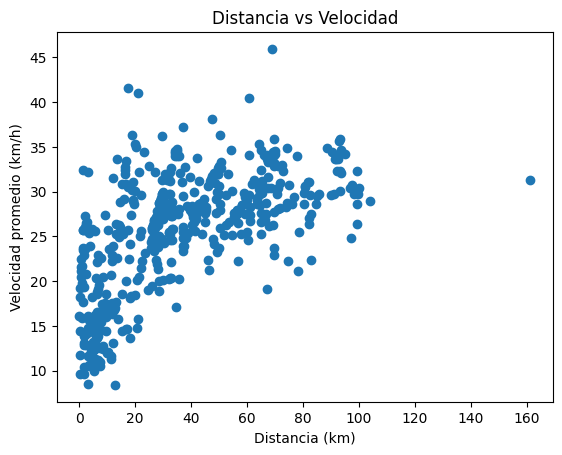

In [14]:
plt.scatter(
    df["distance_km"],
    df["average_speed_kmh"]
)

plt.xlabel("Distancia (km)")
plt.ylabel("Velocidad promedio (km/h)")
plt.title("Distancia vs Velocidad")

plt.show()

## Que nos dice este scatter plot? el comportamiento real de los ciclistas
Zona 0–20 km (izquierda): dispersión vertical enorme, velocidades de 8 a 42 km/h. Tiene sentido: Rutas cortas las hacen tanto principiantes como avanzados, unos entrenando intervalos intensos, otros dando un paseo.

Zona 20–60 km (centro): la nube se compacta y sube. La mayoría converge entre 25–35 km/h. Aquí están los ciclistas más consistentes, rutas medias con un perfil de esfuerzo más estable.

Zona 60–160 km (derecha): muy pocos puntos pero todos en el rango 25–35 km/h. Esto es clave: los ciclistas de larga distancia no son necesariamente los más rápidos, mantienen una velocidad eficiente para aguantar el esfuerzo prolongado.

En conclusion la velocidad y distancia no tienen una correlación lineal fuerte. Un ciclista rápido no siempre hace rutas largas, y uno de larga distancia no siempre es el más veloz. 


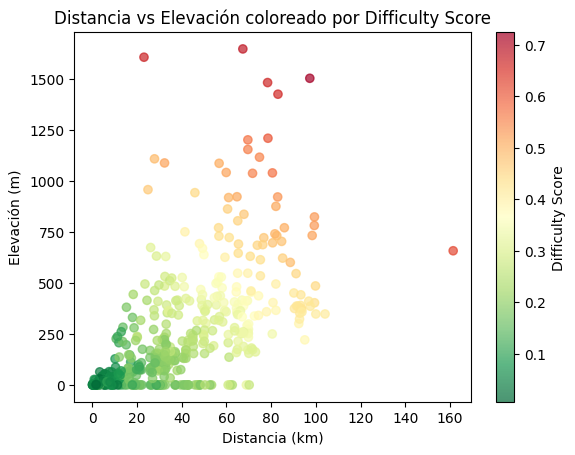

In [15]:
plt.scatter(
    df["distance_km"],
    df["elevation_m"],
    c=df["difficulty_score"],
    cmap="RdYlGn_r",
    alpha=0.7
)

plt.colorbar(label="Difficulty Score")
plt.xlabel("Distancia (km)")
plt.ylabel("Elevación (m)")
plt.title("Distancia vs Elevación coloreado por Difficulty Score")

plt.show()

El gráfico muestra que el scoring captura bien la dificultad combinada:

Verde (abajo izquierda): rutas cortas y planas → fáciles → Beginner

Amarillo (centro): distancia y elevación medias → Intermediate

Rojo (arriba): poca distancia pero mucho desnivel → las más exigentes → Advanced

El punto clave es el outlier de 160 km en amarillo — ruta larga pero plana, el scoring la clasifica correctamente como Intermediate porque la elevación pesa más que la distancia.

# ==========================
# KMEANS CLUSTERING
# ==========================

  CARACTERÍSTICAS PROMEDIO POR NIVEL DE DIFICULTAD

  [Verde] Principiante  (40 rutas)
    Distancia promedio : 14.3 km
    Elevacion promedio : 149 m
    Velocidad promedio : 15.8 km/h

  [Amarillo] Intermedio  (40 rutas)
    Distancia promedio : 44.8 km
    Elevacion promedio : 607 m
    Velocidad promedio : 22.4 km/h

  [Rojo] Avanzado  (40 rutas)
    Distancia promedio : 90.1 km
    Elevacion promedio : 1438 m
    Velocidad promedio : 27.8 km/h


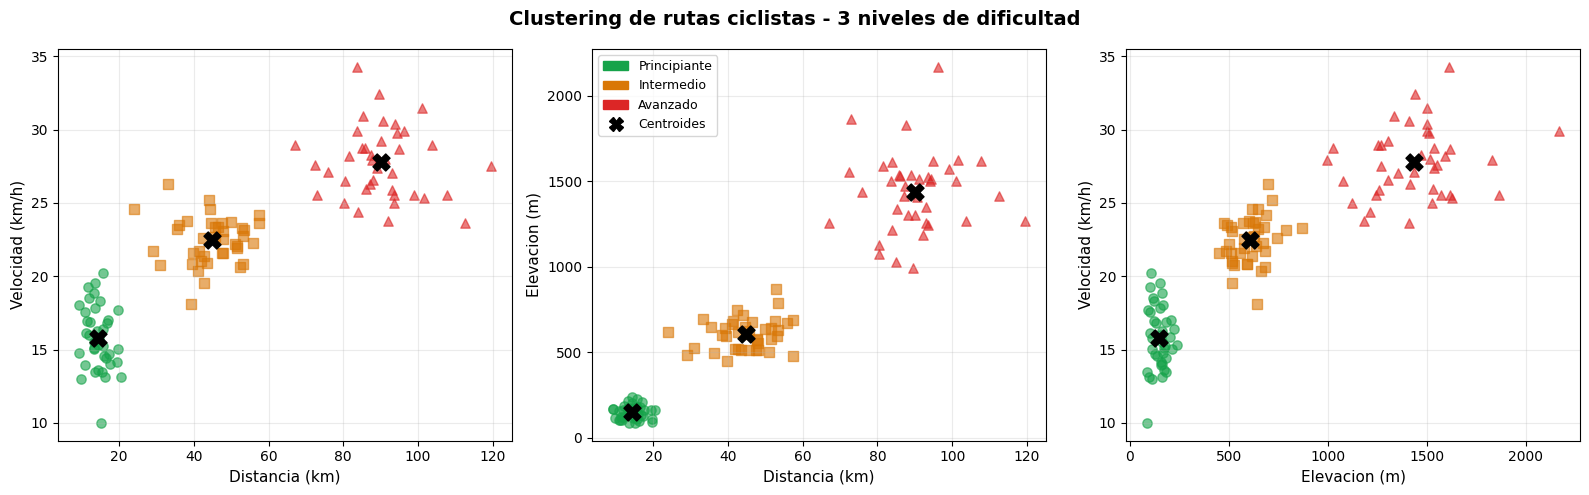


  DEMO: RECOMENDACION DE RUTAS

Perfil del ciclista:
   Distancia max  : 18 km
   Elevacion max  : 200 m
   Velocidad prom : 17 km/h

   Nivel asignado : [Verde] Principiante
   + Rutas de reto del siguiente nivel: [Amarillo] Intermedio

 route_id    name  distance_km  elevation_m  average_speed_kmh                 nivel
       20 Ruta_20    10.763089   100.765427          17.549268  [Verde] Principiante
       17 Ruta_17    11.961507   118.669868          18.533822  [Verde] Principiante
       16 Ruta_16    13.313137   211.997376          15.031532  [Verde] Principiante
       27 Ruta_27    11.547019   100.521972          19.264823  [Verde] Principiante
        5  Ruta_5    14.297540   173.474284          13.599407  [Verde] Principiante
       60 Ruta_60    52.804361   872.016917          23.259258 [Amarillo] Intermedio
       57 Ruta_57    38.286260   601.300189          23.799200 [Amarillo] Intermedio

-------------------------------------------------------

Perfil del ciclista:
  

In [ ]:
"""
=============================================================
MÓDULO DE CLUSTERING DE RUTAS CICLISTAS
=============================================================
Propósito:
    Agrupa las rutas disponibles en niveles de dificultad
    (Principiante, Intermedio, Avanzado) usando K-Means.
    Estos grupos se usan luego para recomendarle al usuario
    las rutas más adecuadas según su nivel actual de condición.

Lógica del sistema de recomendación:
    1. Se entrena K-Means con las características de las rutas
       (distancia, elevación, velocidad).
    2. Cada ruta queda asignada a un cluster / nivel.
    3. Cuando un usuario registra su perfil (distancia máxima
       que recorre, velocidad promedio, etc.), el sistema lo
       ubica en un cluster y le recomienda rutas de ese nivel
       e, incluso, rutas del nivel siguiente para que progrese.
=============================================================
"""

import warnings
warnings.filterwarnings("ignore", category=UserWarning)   # emojis en matplotlib
warnings.filterwarnings("ignore", category=FutureWarning) # avisos de sklearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler


# ==============================================================
# 1. DATOS DE EJEMPLO
#    (En producción este DataFrame viene de tu base de datos)
# ==============================================================

np.random.seed(42)
n = 120

data = {
    "route_id":          range(1, n + 1),
    "name":              [f"Ruta_{i}" for i in range(1, n + 1)],
    "distance_km":       np.concatenate([
                             np.random.normal(15, 3, 40),   # rutas cortas
                             np.random.normal(45, 8, 40),   # rutas medias
                             np.random.normal(90, 12, 40),  # rutas largas
                         ]),
    "elevation_m":       np.concatenate([
                             np.random.normal(150, 40, 40),
                             np.random.normal(600, 100, 40),
                             np.random.normal(1400, 200, 40),
                         ]),
    "average_speed_kmh": np.concatenate([
                             np.random.normal(16, 2, 40),
                             np.random.normal(22, 2, 40),
                             np.random.normal(28, 3, 40),
                         ]),
}

df = pd.DataFrame(data)
df["distance_km"]        = df["distance_km"].clip(5)
df["elevation_m"]        = df["elevation_m"].clip(50)
df["average_speed_kmh"]  = df["average_speed_kmh"].clip(10)


# ==============================================================
# 2. NORMALIZACIÓN Y ENTRENAMIENTO K-MEANS
# ==============================================================
# Normalizamos las 3 características a escala [0, 1] para que
# distancia, elevación y velocidad tengan el mismo peso al
# calcular distancias en el espacio del clustering.
# random_state=42 garantiza reproducibilidad del modelo.
# n_init=10 (valor recomendado): corre el algoritmo 10 veces
# con centroides iniciales distintos y elige el mejor resultado.
# ==============================================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(
    df[["distance_km", "elevation_m", "average_speed_kmh"]]
)

df["dist_norm"]  = X_scaled[:, 0]
df["elev_norm"]  = X_scaled[:, 1]
df["speed_norm"] = X_scaled[:, 2]

X = df[["dist_norm", "elev_norm", "speed_norm"]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)


# ==============================================================
# 3. INTERPRETACIÓN Y ETIQUETADO DE CLUSTERS
# ==============================================================
# K-Means asigna IDs arbitrarios (0, 1, 2). Los reordenamos
# según distancia promedio ascendente para etiquetar de forma
# legible: Principiante < Intermedio < Avanzado.
# ==============================================================

cluster_stats = (
    df.groupby("cluster")[["distance_km", "elevation_m", "average_speed_kmh"]]
    .mean()
    .sort_values("distance_km")
)

# Etiquetas en texto plano (sin emojis) para compatibilidad con matplotlib
ETIQUETAS_PRINT = ["[Verde] Principiante", "[Amarillo] Intermedio", "[Rojo] Avanzado"]
ETIQUETAS_PLOT  = ["Principiante",          "Intermedio",            "Avanzado"]

nivel_map      = {}  # cluster_id -> etiqueta print
nivel_map_plot = {}  # cluster_id -> etiqueta plot

for i, cluster_id in enumerate(cluster_stats.index):
    nivel_map[cluster_id]      = ETIQUETAS_PRINT[i]
    nivel_map_plot[cluster_id] = ETIQUETAS_PLOT[i]

df["nivel"]      = df["cluster"].map(nivel_map)
df["nivel_plot"] = df["cluster"].map(nivel_map_plot)

print("=" * 55)
print("  CARACTERÍSTICAS PROMEDIO POR NIVEL DE DIFICULTAD")
print("=" * 55)
for cluster_id in cluster_stats.index:
    stats  = cluster_stats.loc[cluster_id]
    nivel  = nivel_map[cluster_id]
    n_rutas = (df["cluster"] == cluster_id).sum()
    print(f"\n  {nivel}  ({n_rutas} rutas)")
    print(f"    Distancia promedio : {stats['distance_km']:.1f} km")
    print(f"    Elevacion promedio : {stats['elevation_m']:.0f} m")
    print(f"    Velocidad promedio : {stats['average_speed_kmh']:.1f} km/h")
print("=" * 55)


# ==============================================================
# 4. VISUALIZACIÓN DE CLUSTERS
# ==============================================================
# 3 vistas complementarias para ver la separación desde
# distintos ángulos:
#   - Distancia vs Velocidad  (esfuerzo general)
#   - Distancia vs Elevación  (dificultad del terreno)
#   - Elevación vs Velocidad
# Los centroides están marcados con X para identificar
# el "centro" de cada grupo.
# ==============================================================

COLORS  = {"Principiante": "#16A34A", "Intermedio": "#D97706", "Avanzado": "#DC2626"}
MARKERS = {"Principiante": "o",       "Intermedio": "s",       "Avanzado": "^"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Clustering de rutas ciclistas - 3 niveles de dificultad",
    fontsize=14, fontweight="bold"
)

ejes = [
    ("distance_km", "average_speed_kmh", "Distancia (km)", "Velocidad (km/h)"),
    ("distance_km", "elevation_m",        "Distancia (km)", "Elevacion (m)"),
    ("elevation_m", "average_speed_kmh",  "Elevacion (m)",  "Velocidad (km/h)"),
]

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, ejes):
    for nivel_p in ETIQUETAS_PLOT:
        mask = df["nivel_plot"] == nivel_p
        ax.scatter(
            df.loc[mask, xcol],
            df.loc[mask, ycol],
            c=COLORS[nivel_p],
            marker=MARKERS[nivel_p],
            alpha=0.6,
            s=45,
            label=nivel_p,
        )
    # Centroides en espacio original (invertimos la normalización)
    centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
    col_idx = {"distance_km": 0, "elevation_m": 1, "average_speed_kmh": 2}
    ax.scatter(
        centroids_original[:, col_idx[xcol]],
        centroids_original[:, col_idx[ycol]],
        c="black", marker="X", s=150, zorder=5, label="Centroides",
    )
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(alpha=0.25)

# Leyenda única en el gráfico central
handles = [
    mpatches.Patch(color=COLORS[n], label=n) for n in ETIQUETAS_PLOT
] + [plt.Line2D([0], [0], marker="X", color="black", linestyle="None",
                markersize=10, label="Centroides")]
axes[1].legend(handles=handles, fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("clusters_visualizacion.png", dpi=150)
plt.show()


# ==============================================================
# 5. FUNCIÓN DE RECOMENDACIÓN POR NIVEL DE USUARIO
# ==============================================================
# Recibe el perfil de rendimiento del ciclista, lo normaliza
# con el mismo scaler del entrenamiento y predice su cluster.
# Devuelve rutas de su nivel más, opcionalmente, rutas del
# nivel siguiente para estimular la progresión.
# ==============================================================

def recomendar_rutas(dist_max_km: float,
                     elev_max_m: float,
                     speed_avg_kmh: float,
                     incluir_siguiente_nivel: bool = True,
                     n_rutas: int = 5) -> pd.DataFrame:
    """
    Recomienda rutas a un ciclista según su perfil de rendimiento.

    Args:
        dist_max_km            : Distancia maxima que el ciclista puede recorrer (km).
        elev_max_m             : Elevacion acumulada maxima con la que se siente comodo (m).
        speed_avg_kmh          : Velocidad promedio habitual del ciclista (km/h).
        incluir_siguiente_nivel: Si True, añade rutas del nivel inmediato superior
                                 para estimular la progresion.
        n_rutas                : Numero de rutas a devolver por nivel.

    Returns:
        DataFrame con las rutas recomendadas y su nivel de dificultad.
    """
    perfil      = np.array([[dist_max_km, elev_max_m, speed_avg_kmh]])
    perfil_norm = scaler.transform(perfil)

    cluster_usuario = kmeans.predict(perfil_norm)[0]
    nivel_usuario   = nivel_map[cluster_usuario]
    nivel_plot_u    = nivel_map_plot[cluster_usuario]

    print(f"\nPerfil del ciclista:")
    print(f"   Distancia max  : {dist_max_km} km")
    print(f"   Elevacion max  : {elev_max_m} m")
    print(f"   Velocidad prom : {speed_avg_kmh} km/h")
    print(f"\n   Nivel asignado : {nivel_usuario}")

    rutas_actuales = (
        df[df["nivel_plot"] == nivel_plot_u]
        .sample(n=min(n_rutas, (df["nivel_plot"] == nivel_plot_u).sum()), random_state=42)
        [["route_id", "name", "distance_km", "elevation_m", "average_speed_kmh", "nivel"]]
    )

    if incluir_siguiente_nivel:
        idx_nivel = ETIQUETAS_PLOT.index(nivel_plot_u)
        if idx_nivel < len(ETIQUETAS_PLOT) - 1:
            siguiente_plot  = ETIQUETAS_PLOT[idx_nivel + 1]
            siguiente_print = ETIQUETAS_PRINT[idx_nivel + 1]
            rutas_siguiente = (
                df[df["nivel_plot"] == siguiente_plot]
                .sample(n=min(n_rutas // 2, (df["nivel_plot"] == siguiente_plot).sum()), random_state=42)
                [["route_id", "name", "distance_km", "elevation_m", "average_speed_kmh", "nivel"]]
            )
            resultado = pd.concat([rutas_actuales, rutas_siguiente], ignore_index=True)
            print(f"   + Rutas de reto del siguiente nivel: {siguiente_print}\n")
        else:
            resultado = rutas_actuales
            print("   (Ya estas en el nivel mas alto, bien hecho!)\n")
    else:
        resultado = rutas_actuales

    return resultado


# ==============================================================
# 6. EJEMPLO DE USO DE LA FUNCIÓN DE RECOMENDACIÓN
# ==============================================================

print("\n" + "=" * 55)
print("  DEMO: RECOMENDACION DE RUTAS")
print("=" * 55)

recomendaciones = recomendar_rutas(
    dist_max_km=18,
    elev_max_m=200,
    speed_avg_kmh=17,
)
print(recomendaciones.to_string(index=False))

print("\n" + "-" * 55)

recomendaciones2 = recomendar_rutas(
    dist_max_km=48,
    elev_max_m=650,
    speed_avg_kmh=23,
)
print(recomendaciones2.to_string(index=False))